
# Bifurcation & Stability Explorer

A general-purpose tool for discrete dynamical maps $x_{n+1} = g(x_n; r)$ (or systems of maps):
given a symbolic map and a parameter, it

1. finds fixed points as the parameter varies,
2. computes the Jacobian and classifies stability via the **Jury conditions**,
3. renders the classic bifurcation diagram,
4. is validated against the **logistic map** (known analytic bifurcation structure) and against
   your own **Nicholson-Bailey** model, so the tool is proven against ground truth before you
   trust it on anything new.

No GPU needed — this runs entirely on CPU, so it won't eat into your Kaggle GPU quota.


In [1]:

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()


## 1. Symbolic engine

Accepts a map (1-D or n-D) as a sympy expression, finds fixed points symbolically/numerically, and computes the Jacobian.

In [2]:

class DiscreteMap:
    '''
    Wraps a discrete dynamical system x_{n+1} = g(x_n; params).

    variables : list of sympy symbols, e.g. [x] or [x, y]
    expr      : list of sympy expressions, one per variable, e.g. [r*x*(1-x)]
    param     : the sympy symbol used as the bifurcation parameter, e.g. r
    '''
    def __init__(self, variables, expr, param):
        self.vars = variables
        self.expr = expr
        self.param = param
        self.n = len(variables)

        # Jacobian d(g_i)/d(x_j), still symbolic in (x, param)
        self.J_sym = sp.Matrix(expr).jacobian(sp.Matrix(variables))

        # Lambdified numeric versions for fast repeated evaluation
        self._g_num = sp.lambdify(variables + [param], expr, 'numpy')
        self._J_num = sp.lambdify(variables + [param], self.J_sym, 'numpy')

    def iterate(self, x0, param_val, n_steps):
        x = np.array(x0, dtype=float)
        traj = [x.copy()]
        for _ in range(n_steps):
            x = np.array(self._g_num(*x, param_val), dtype=float).reshape(-1)
            traj.append(x.copy())
        return np.array(traj)

    def fixed_points(self, param_val, guesses=None, n_random_guesses=25):
        '''Numerically solve g(x) = x for the given parameter value.'''
        if guesses is None:
            rng = np.random.default_rng(0)
            guesses = [rng.uniform(-2, 2, size=self.n) for _ in range(n_random_guesses)]

        def residual(x):
            gx = np.array(self._g_num(*x, param_val), dtype=float).reshape(-1)
            return gx - np.array(x)

        from scipy.optimize import fsolve
        found = []
        for g0 in guesses:
            sol, info, ier, msg = fsolve(residual, g0, full_output=True)
            if ier == 1:
                sol = np.round(sol, 8)
                if not any(np.allclose(sol, f, atol=1e-6) for f in found):
                    found.append(sol)
        return found

    def jacobian_at(self, x_star, param_val):
        return np.array(self._J_num(*x_star, param_val), dtype=float)



## 2. Jury stability test

For a discrete-time linear(ized) system, a fixed point is stable iff every eigenvalue of the
Jacobian lies inside the unit circle. For 1-D and 2-D systems this can be checked directly from
the characteristic polynomial coefficients via the **Jury conditions**, without ever computing
eigenvalues explicitly — useful because it stays exact/symbolic-friendly and generalizes cleanly.

For the general n-D case we fall back to checking eigenvalue magnitudes directly (equivalent
result, simpler to implement correctly for arbitrary dimension).


In [3]:

def jury_stable_1d(a):
    '''1-D map: characteristic 'polynomial' is just lambda - a = 0 -> stable iff |a| < 1.'''
    return abs(a) < 1


def jury_stable_2d(J):
    '''
    2x2 Jacobian. Characteristic polynomial: lambda^2 - (trace)lambda + det = 0.
    Jury conditions for a 2nd-order polynomial lambda^2 + a1 lambda + a0 = 0:
        |a0| < 1
        |a1| < 1 + a0
    with a1 = -trace(J), a0 = det(J).
    '''
    a0 = np.linalg.det(J)
    a1 = -np.trace(J)
    cond1 = abs(a0) < 1
    cond2 = abs(a1) < 1 + a0
    return bool(cond1 and cond2)


def stable_by_eigenvalues(J):
    '''General n-D fallback: stable iff all eigenvalues lie strictly inside the unit circle.'''
    eigs = np.linalg.eigvals(J)
    return bool(np.all(np.abs(eigs) < 1))


def classify_stability(J):
    n = J.shape[0]
    if n == 1:
        stable = jury_stable_1d(J[0, 0])
    elif n == 2:
        stable = jury_stable_2d(J)
    else:
        stable = stable_by_eigenvalues(J)
    return 'stable' if stable else 'unstable'


## 3. Bifurcation diagram generator

Standard approach: for each parameter value, iterate the map for many steps, discard the transient, and scatter-plot what remains.

In [4]:

def bifurcation_diagram(dyn_map, param_range, x0=0.5, n_iter=1000, n_discard=800,
                         component=0, figsize=(9, 6)):
    r_vals = np.linspace(*param_range[:2], int(param_range[2]))
    rs_plot, xs_plot = [], []

    for r in r_vals:
        traj = dyn_map.iterate([x0] * dyn_map.n, r, n_iter)
        tail = traj[n_discard:, component]
        rs_plot.extend([r] * len(tail))
        xs_plot.extend(tail)

    plt.figure(figsize=figsize)
    plt.plot(rs_plot, xs_plot, ',k', alpha=0.4, markersize=0.5)
    plt.xlabel(str(dyn_map.param))
    plt.ylabel(f'{dyn_map.vars[component]} (long-run)')
    plt.title('Bifurcation diagram')
    plt.tight_layout()
    return plt.gcf()



## 4. Validation #1: the logistic map

The logistic map $x_{n+1} = r x_n (1 - x_n)$ has a well-known bifurcation structure
(period-doubling cascade to chaos starting around $r \approx 3.0$, full chaos onset near
$r \approx 3.57$). If the tool reproduces this, it's trustworthy.


In [5]:

x, r = sp.symbols('x r')
logistic = DiscreteMap(variables=[x], expr=[r * x * (1 - x)], param=r)

# Fixed points and stability at a few sample r values
for r_val in [0.5, 2.5, 3.2, 3.6]:
    fps = logistic.fixed_points(r_val)
    print(f'r = {r_val}')
    for fp in fps:
        J = logistic.jacobian_at(fp, r_val)
        print(f'  fixed point {fp}  ->  {classify_stability(J)}  (J = {J.ravel()})')


r = 0.5
  fixed point [0.]  ->  stable  (J = [0.5])
  fixed point [-1.]  ->  unstable  (J = [1.5])
r = 2.5
  fixed point [0.6]  ->  stable  (J = [-0.5])
  fixed point [0.]  ->  unstable  (J = [2.5])
r = 3.2
  fixed point [0.6875]  ->  unstable  (J = [-1.2])
  fixed point [0.]  ->  unstable  (J = [3.2])
r = 3.6
  fixed point [0.72222222]  ->  unstable  (J = [-1.59999998])
  fixed point [0.]  ->  unstable  (J = [3.6])


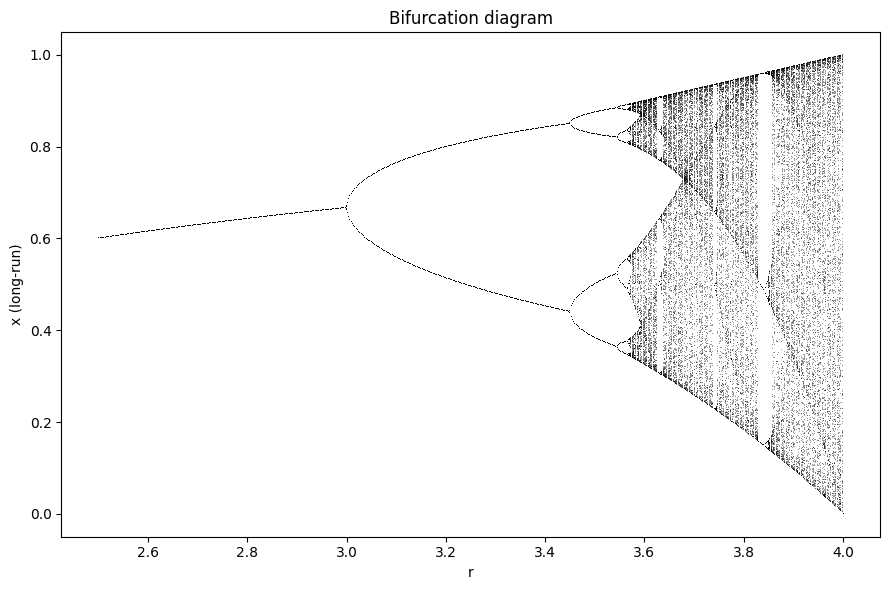

In [6]:

fig = bifurcation_diagram(logistic, param_range=(2.5, 4.0, 600), x0=0.5,
                           n_iter=1000, n_discard=800)
plt.savefig('logistic_bifurcation.png', dpi=150)
plt.show()



## 5. Validation #2: your Nicholson-Bailey model

Classic host-parasitoid model:

$$ H_{n+1} = \lambda H_n e^{-a P_n}, \qquad P_{n+1} = c H_n (1 - e^{-a P_n}) $$

Known to have an unstable positive equilibrium for the basic (unmodified) version — a good
sanity check that the 2-D Jury test and fixed-point solver agree with the textbook result.
Swap in whatever modified/stabilized variant you used in your Kansas State project to reproduce
*those* results instead.


In [7]:

H, P, lam, a_par, c_par = sp.symbols('H P lambda a c', positive=True)

H_next = lam * H * sp.exp(-a_par * P)
P_next = c_par * H * (1 - sp.exp(-a_par * P))

# Fix c and a, vary lambda as the bifurcation parameter for the demo
c_val, a_val = 1.0, 1.0
nb_expr = [H_next.subs({c_par: c_val, a_par: a_val}),
           P_next.subs({c_par: c_val, a_par: a_val})]

nicholson_bailey = DiscreteMap(variables=[H, P], expr=nb_expr, param=lam)

for lam_val in [1.5, 2.0, 3.0]:
    fps = nicholson_bailey.fixed_points(lam_val, guesses=[[1.0, 1.0], [2.0, 0.5]])
    print(f'lambda = {lam_val}')
    for fp in fps:
        if np.any(fp <= 1e-6):
            continue  # skip the trivial extinction equilibrium
        J = nicholson_bailey.jacobian_at(fp, lam_val)
        print(f'  fixed point {fp}  ->  {classify_stability(J)}')


lambda = 1.5
  fixed point [1.21639532 0.40546511]  ->  unstable
lambda = 2.0
  fixed point [1.38629436 0.69314718]  ->  unstable
lambda = 3.0
  fixed point [1.64791843 1.09861229]  ->  unstable



## 6. Interactive front-end (Streamlit)

Run locally with `streamlit run app.py` (write the cell below to `app.py` first). This is what
turns the notebook into a portfolio piece: a user pastes their own map and instantly gets fixed
points, stability, and a bifurcation diagram.


In [8]:

app_code = r"""
import streamlit as st
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

st.title("Bifurcation & Stability Explorer")

st.markdown("Enter a 1-D map as a function of `x` and parameter `r`, e.g. `r*x*(1-x)`")
expr_str = st.text_input("x_next =", "r*x*(1-x)")
r_min = st.number_input("parameter min", value=2.5)
r_max = st.number_input("parameter max", value=4.0)
n_iter = st.slider("iterations per parameter value", 200, 3000, 1000)
n_discard = st.slider("transient discarded", 0, 2500, 800)

x, r = sp.symbols("x r")
try:
    expr = sp.sympify(expr_str)
    g = sp.lambdify((x, r), expr, "numpy")

    r_vals = np.linspace(r_min, r_max, 600)
    rs_plot, xs_plot = [], []
    x0 = 0.5
    for rv in r_vals:
        xv = x0
        traj = []
        for i in range(n_iter):
            xv = g(xv, rv)
            if i >= n_discard:
                traj.append(xv)
        rs_plot.extend([rv] * len(traj))
        xs_plot.extend(traj)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(rs_plot, xs_plot, ",k", alpha=0.4, markersize=0.5)
    ax.set_xlabel("r")
    ax.set_ylabel("x (long-run)")
    st.pyplot(fig)
except Exception as e:
    st.error(f"Could not parse/evaluate expression: {e}")
"""

with open('app.py', 'w') as f:
    f.write(app_code)

print("Wrote app.py -- run locally with: streamlit run app.py")


Wrote app.py -- run locally with: streamlit run app.py



## 7. Next steps to make this "your" project

1. **Swap in your actual Kansas State model** (the stabilized/modified Nicholson-Bailey variant,
   or whatever map you studied) in place of the plain version above, and reproduce the exact
   result from your prior work — that's your validation story for the README.
2. **Extend the Jury test to n=3** if any of your models are 3-D (the general eigenvalue fallback
   already works for any dimension, but an explicit symbolic Jury test for n=3 is a nice extra if
   you want to show more rigor).
3. **Package the repo**:
   ```
   bifurcation-explorer/
   ├── src/
   │   ├── engine.py        (DiscreteMap, fixed_points, jacobian_at)
   │   ├── stability.py     (jury_stable_1d/2d, classify_stability)
   │   └── bifurcation.py   (bifurcation_diagram)
   ├── app.py                (Streamlit front-end)
   ├── examples/
   │   ├── logistic_map.ipynb
   │   └── nicholson_bailey.ipynb
   └── README.md   (state validation against known results up front)
   ```
4. **CV bullet point**: "Built a general-purpose bifurcation analysis tool with automated Jury
   stability classification; validated against the logistic map's known period-doubling cascade
   and against my own Nicholson-Bailey host-parasitoid model."
